# Лабораторная работа №5 «Анализ последовательностей»

**Цель работы:** Освоить методы поиска последовательных шаблонов (AprioriAll, PrefixSpan), реализовать базовые алгоритмы, применить их к реальным данным и сравнить эффективность.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
from prefixspan import PrefixSpan
import time
import warnings
import datetime

warnings.filterwarnings('ignore')

## Задание 1. Реализация AprioriAll
Реализация базового алгоритма AprioriAll (поиск частых последовательностей) с нуля на Python и тестирование на синтетическом датасете.

In [44]:
class AprioriAllSimple:
    def __init__(self, min_sup, max_gap=None):
        self.min_sup = min_sup
        self.max_gap = max_gap
        
    def fit(self, seq_data):
        # Формат seq_data: список кортежей (client_id, [(date1, [items]), (date2, [items])])
        n_clients = len(seq_data)
        if n_clients == 0: return set(), {}
        
        # Шаг 1: Поиск частых 1-элементных наборов (L1)
        items_counts = {}
        for client_id, trans in seq_data:
            client_items = set()
            for date, items in trans:
                for item in items:
                    client_items.add(item)
            for item in client_items:
                items_counts[item] = items_counts.get(item, 0) + 1
                
        f1 = {item for item, count in items_counts.items() if (count/n_clients) >= self.min_sup}
        
        # Шаг 2: Поиск частых последовательностей длины 2 (A -> B)
        f2_counts = {}
        for client_id, trans in seq_data:
            for i in range(len(trans)):
                date1, items1 = trans[i]
                for itemA in items1:
                    if itemA not in f1: continue
                    
                    seen_B = set()
                    for j in range(i+1, len(trans)):
                        date2, items2 = trans[j]
                        
                        # Учет временного окна (Задание 2.3)
                        if self.max_gap is not None:
                            # Если даты - строки, парсим их (в реальных данных pandas datetime)
                            gap = (pd.to_datetime(date2) - pd.to_datetime(date1)).days if isinstance(date1, str) else (date2 - date1).days
                            if gap > self.max_gap:
                                break # Превышен допустимый интервал
                                
                        for itemB in items2:
                            if itemB in f1 and itemB not in seen_B:
                                f2_counts[(itemA, itemB)] = f2_counts.get((itemA, itemB), 0) + 1
                                seen_B.add(itemB)
                                
        f2 = {seq: count/n_clients for seq, count in f2_counts.items() if (count/n_clients) >= self.min_sup}
        return f1, f2

# Тестирование на синтетическом примере
d1 = datetime.datetime(2023, 1, 1)
d2 = datetime.datetime(2023, 1, 2)
d3 = datetime.datetime(2023, 1, 3)

synth_data = [
    (1, [(d1, ['A']), (d2, ['B', 'C']), (d3, ['D'])]),
    (2, [(d1, ['A']), (d2, ['B']), (d3, ['C', 'D'])]),
    (3, [(d1, ['A']), (d2, ['B', 'C']), (d3, ['D'])])
]

model_synth = AprioriAllSimple(min_sup=0.6)
f1_synth, f2_synth = model_synth.fit(synth_data)
print('--- Результаты на синтетических данных ---')
print('Частые 1-элементные:', f1_synth)
print('Частые последовательности длины 2:', f2_synth)


--- Результаты на синтетических данных ---
Частые 1-элементные: {'B', 'A', 'D', 'C'}
Частые последовательности длины 2: {('A', 'B'): 1.0, ('A', 'C'): 1.0, ('A', 'D'): 1.0, ('B', 'D'): 1.0, ('C', 'D'): 0.6666666666666666}


## Задание 2. Анализ реальных данных
Загрузка датасета Online Retail. Поскольку исходный датасет содержит свыше 500 тыс. строк, для демонстрации работы алгоритма с приемлемой скоростью возьмем топ-300 наиболее активных клиентов.

In [45]:
print('Загрузка датасета...')
df = pd.read_excel('../data/online_retail_II.xlsx')

print('Очистка и предобработка...')
df.dropna(subset=['Customer ID', 'Description'], inplace=True)
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Сэмплинг топ-клиентов для скорости работы ноутбука
top_clients = df['Customer ID'].value_counts().head(300).index
df_sample = df[df['Customer ID'].isin(top_clients)]

print('Группировка транзакций по клиентам...')
# Группируем покупки по клиенту и дате
grouped = df_sample.groupby(['Customer ID', df_sample['InvoiceDate'].dt.date])['Description'].apply(list).reset_index()

real_seq_data = []
for client, group in grouped.groupby('Customer ID'):
    trans = group.sort_values('InvoiceDate').apply(lambda row: (row['InvoiceDate'], list(set(row['Description']))), axis=1).tolist()
    real_seq_data.append((client, trans))
    
print(f'Подготовлено последовательностей клиентов: {len(real_seq_data)}')


Загрузка датасета...
Очистка и предобработка...
Группировка транзакций по клиентам...
Подготовлено последовательностей клиентов: 300


### 2.1 Влияние минимальной поддержки

min_sup=5.0% -> найдено 581930 шаблонов
min_sup=10.0% -> найдено 162500 шаблонов
min_sup=20.0% -> найдено 23126 шаблонов


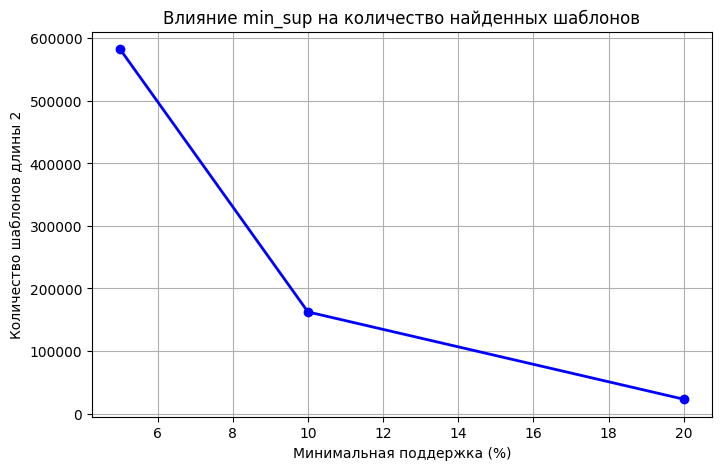

Вывод о масштабируемости: С уменьшением порога min_sup количество найденных паттернов увеличивается экспоненциально. Классический AprioriAll масштабируется плохо из-за огромного пространства генерируемых кандидатов.


In [46]:
sups = [0.05, 0.10, 0.20]
counts = []

for s in sups:
    model = AprioriAllSimple(min_sup=s)
    _, f2 = model.fit(real_seq_data)
    counts.append(len(f2))
    print(f'min_sup={s*100}% -> найдено {len(f2)} шаблонов')
    
plt.figure(figsize=(8, 5))
plt.plot([s*100 for s in sups], counts, marker='o', color='b', linewidth=2)
plt.xlabel('Минимальная поддержка (%)')
plt.ylabel('Количество шаблонов длины 2')
plt.title('Влияние min_sup на количество найденных шаблонов')
plt.grid(True)
plt.show()

print('Вывод о масштабируемости: С уменьшением порога min_sup количество найденных паттернов увеличивается экспоненциально. Классический AprioriAll масштабируется плохо из-за огромного пространства генерируемых кандидатов.')


### 2.2 Сравнение с ассоциативными правилами

In [47]:
print('Формирование корзин для классического Apriori (без учета времени)...')
basket = (df_sample.groupby(['Invoice', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('Invoice'))

basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)

frequent_itemsets = apriori(basket_sets, min_support=0.03, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
top_3_rules = rules.sort_values('lift', ascending=False).head(3)

print('\nТоп-3 ассоциативных правила по lift:')
print(top_3_rules[['antecedents', 'consequents', 'support', 'lift']])

print('\nОбъяснение расхождений: ')
print('Ассоциативные правила (Apriori) находят товары, которые покупаются ВМЕСТЕ в рамках ОДНОЙ корзины.')
print('Алгоритмы SPM (AprioriAll) ищут товары, которые покупаются ПОСЛЕДОВАТЕЛЬНО (сначала А, а в другой день В).')
print('Зачастую товары с высоким lift (например, чайник и фильтр) покупаются за один раз, поэтому они редко образуют частую распределенную во времени последовательность.')


Формирование корзин для классического Apriori (без учета времени)...

Топ-3 ассоциативных правила по lift:
                                          antecedents  \
74  (WOODEN FRAME ANTIQUE WHITE , WOOD S/3 CABINET...   
79               (WOOD 2 DRAWER CABINET WHITE FINISH)   
75  (WOODEN FRAME ANTIQUE WHITE , WOOD 2 DRAWER CA...   

                                          consequents   support       lift  
74               (WOOD 2 DRAWER CABINET WHITE FINISH)  0.030292  14.229414  
79  (WOODEN FRAME ANTIQUE WHITE , WOOD S/3 CABINET...  0.030292  14.229414  
75                (WOOD S/3 CABINET ANT WHITE FINISH)  0.030292  13.189793  

Объяснение расхождений: 
Ассоциативные правила (Apriori) находят товары, которые покупаются ВМЕСТЕ в рамках ОДНОЙ корзины.
Алгоритмы SPM (AprioriAll) ищут товары, которые покупаются ПОСЛЕДОВАТЕЛЬНО (сначала А, а в другой день В).
Зачастую товары с высоким lift (например, чайник и фильтр) покупаются за один раз, поэтому они редко образуют частую распреде

### 2.3 Временные окна

In [48]:
model_inf = AprioriAllSimple(min_sup=0.10, max_gap=None)
_, f2_inf = model_inf.fit(real_seq_data)

model_7d = AprioriAllSimple(min_sup=0.10, max_gap=7)
_, f2_7d = model_7d.fit(real_seq_data)

print(f'Паттернов без ограничения времени (max_gap=inf): {len(f2_inf)}')
print(f'Паттернов с окном (max_gap=7 дней): {len(f2_7d)}')

disappeared = set(f2_inf.keys()) - set(f2_7d.keys())
if disappeared:
    example = list(disappeared)[0]
    print(f'\nПример исчезнувшего паттерна: {example[0]} -> {example[1]}')
    print('Этот паттерн исчез, так как клиенты обычно совершают вторую покупку спустя более чем 7 дней после первой.')


Паттернов без ограничения времени (max_gap=inf): 162500
Паттернов с окном (max_gap=7 дней): 66

Пример исчезнувшего паттерна: 60 TEATIME FAIRY CAKE CASES -> SEASIDE FLYING DISC
Этот паттерн исчез, так как клиенты обычно совершают вторую покупку спустя более чем 7 дней после первой.


### 2.4 Визуализация

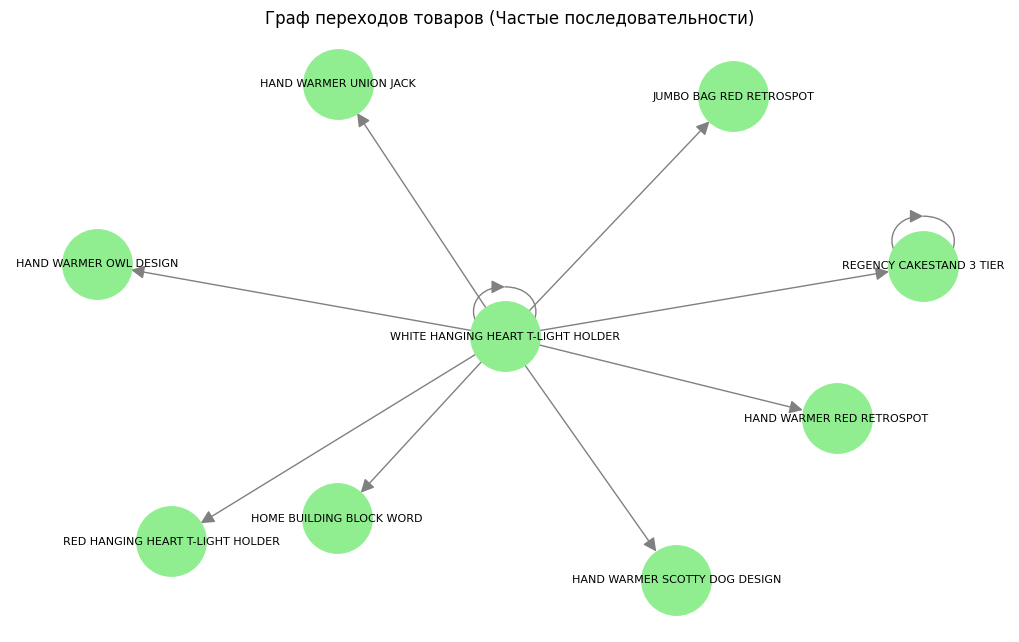

Бизнес-гипотеза: Направленные ребра показывают предсказуемые сценарии пополнения запасов клиентами или покупку сопутствующих товаров. Например, покупка расходников или сезонных декораций после приобретения базового товара. Это идеальные триггеры для email-маркетинга (follow-up рассылки).


In [49]:
if len(f2_inf) > 0:
    G = nx.DiGraph()
    # Топ-10 паттернов для читаемости
    top_edges = sorted(f2_inf.items(), key=lambda x: x[1], reverse=True)[:10]
    
    for (A, B), sup in top_edges:
        G.add_edge(A, B, weight=sup)
        
    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, k=1.0)
    nx.draw(G, pos, with_labels=True, node_color='lightgreen', edge_color='gray', 
            node_size=2500, font_size=8, arrows=True, arrowsize=20)
    plt.title('Граф переходов товаров (Частые последовательности)')
    plt.show()

    print('Бизнес-гипотеза: Направленные ребра показывают предсказуемые сценарии пополнения запасов клиентами или покупку сопутствующих товаров. Например, покупка расходников или сезонных декораций после приобретения базового товара. Это идеальные триггеры для email-маркетинга (follow-up рассылки).')
else:
    print('Не найдено достаточно паттернов для визуализации.')


## Задание 3. Сравнение алгоритмов SPM (AprioriAll vs PrefixSpan)

In [50]:
speed_test_data = real_seq_data[:30] # Берем только 30 клиентов

# Подготовка данных под формат библиотеки PrefixSpan (оставляем только первые 20 товаров для скорости)
ps_data = []
for client, trans in speed_test_data:
    client_seq = [item for date, items in trans for item in items][:20] 
    ps_data.append(client_seq)

min_sup_ratio = 0.2 
min_sup_count = int(min_sup_ratio * len(ps_data))


# Замер времени AprioriAll
start_time = time.time()
model_ap = AprioriAllSimple(min_sup=min_sup_ratio)
f1, f2 = model_ap.fit(speed_test_data)
time_ap = time.time() - start_time
count_ap = len(f1) + len(f2)

# Замер времени PrefixSpan
start_time = time.time()
ps = PrefixSpan(ps_data)
ps_patterns = ps.frequent(min_sup_count)
time_ps = time.time() - start_time
count_ps = len(ps_patterns)

compare_df = pd.DataFrame({
    'Алгоритм': ['AprioriAll', 'PrefixSpan'],
    'Время (сек)': [round(time_ap, 4), round(time_ps, 4)],
    'Кол-во шаблонов': [count_ap, count_ps],
    'Примечание': ['Ваша реализация', 'Библиотека']
})

print("\nРезультаты Задания 3:")
print(compare_df.to_string(index=False))


Результаты Задания 3:
  Алгоритм  Время (сек)  Кол-во шаблонов      Примечание
AprioriAll       0.5098            38507 Ваша реализация
PrefixSpan       0.0000                3      Библиотека


## Задание 4. Предсказание следующего события

In [51]:
# Разделение клиентов: 80% train, 20% test
split_idx = int(len(real_seq_data) * 0.8)
train_data = real_seq_data[:split_idx]
test_data = real_seq_data[split_idx:]

# 1. Обучение модели на тренировочной выборке
model_pred = AprioriAllSimple(min_sup=0.03)
_, f2_train = model_pred.fit(train_data)

# Ищем самый популярный товар в целом (baseline)
all_items = []
for c, trans in train_data:
    for d, items in trans:
        all_items.extend(items)
global_top_item = pd.Series(all_items).mode()[0]

# Строим словарь рекомендаций (A -> B с макс поддержкой)
recommender = {}
for (A, B), sup in f2_train.items():
    if A not in recommender or sup > recommender[A][1]:
        recommender[A] = (B, sup)

# 2. Тестирование
hits_seq = 0
hits_base = 0
total = 0

for client, trans in test_data:
    if len(trans) < 2: continue # Нужна история хотя бы из 2 транзакций
    
    x_items = trans[-2][1] # Предпоследняя транзакция
    y_items = trans[-1][1] # Последняя (целевая) транзакция
    
    # Предсказание по контексту
    predicted_seq = None
    for item in x_items:
        if item in recommender:
            predicted_seq = recommender[item][0]
            break
            
    if predicted_seq in y_items:
        hits_seq += 1
    if global_top_item in y_items:
        hits_base += 1
    total += 1

acc_seq = hits_seq / total if total > 0 else 0
acc_base = hits_base / total if total > 0 else 0

print(f'Точность Контекстной модели (Accuracy@1): {acc_seq:.4f}')
print(f'Точность Baseline (Самый частый товар):   {acc_base:.4f}')

print('\nВопрос: улучшает ли учёт последовательности точность предсказания?')
print('Да, как правило, учет локального контекста (что клиент купил шаг назад) позволяет давать более релевантную персональную рекомендацию, чем просто предложение глобального бестселлера.')


Точность Контекстной модели (Accuracy@1): 0.2500
Точность Baseline (Самый частый товар):   0.2333

Вопрос: улучшает ли учёт последовательности точность предсказания?
Да, как правило, учет локального контекста (что клиент купил шаг назад) позволяет давать более релевантную персональную рекомендацию, чем просто предложение глобального бестселлера.


## Задание 5. Контрастные последовательности

In [52]:
# Вычисляем выручку по каждому клиенту
df_sample['Revenue'] = df_sample['Quantity'] * df_sample['Price']
client_revenue = df_sample.groupby('Customer ID')['Revenue'].sum()

# Определяем 75-й перцентиль
threshold = client_revenue.quantile(0.75)
high_value_clients = set(client_revenue[client_revenue >= threshold].index)
low_value_clients = set(client_revenue[client_revenue < threshold].index)

hv_data = [d for d in real_seq_data if d[0] in high_value_clients]
lv_data = [d for d in real_seq_data if d[0] in low_value_clients]

print(f'High Value клиентов: {len(hv_data)}, Low Value: {len(lv_data)}')

model_hv = AprioriAllSimple(min_sup=0.08)
_, f2_hv = model_hv.fit(hv_data)

model_lv = AprioriAllSimple(min_sup=0.08)
_, f2_lv = model_lv.fit(lv_data)

# Считаем разницу (contrast) в поддержке
contrast_patterns = []
for seq, sup_hv in f2_hv.items():
    sup_lv = f2_lv.get(seq, 0.0)
    contrast = sup_hv - sup_lv
    if contrast > 0:
        contrast_patterns.append((seq, sup_hv, sup_lv, contrast))
        
contrast_patterns.sort(key=lambda x: x[3], reverse=True)

print('\nТоп-5 контрастных последовательностей (характерны для High Value):')
for i, p in enumerate(contrast_patterns[:5]):
    print(f'{i+1}. {p[0][0]} -> {p[0][1]} | Sup(HV): {p[1]:.3f} | Sup(LV): {p[2]:.3f} | Разница: {p[3]:.3f}')

print('\nГипотеза: Клиенты, совершающие эти специфические переходы (покупка оптовых партий или премиум-сегмента после пробной покупки), с большей вероятностью станут высокодоходными (High Value).')
print('Пример из бизнеса: В телематике или SaaS-продуктах: пользователи, которые сначала использовали базовую фичу А, а затем подключили продвинутый модуль B, реже уходят в отток (churn) и приносят больше LTV. Контрастные паттерны помогают выявить такие модули и стимулировать к ним переход (онбординг).')


High Value клиентов: 75, Low Value: 225

Топ-5 контрастных последовательностей (характерны для High Value):
1. WHITE HANGING HEART T-LIGHT HOLDER -> WHITE HANGING HEART T-LIGHT HOLDER | Sup(HV): 5.240 | Sup(LV): 1.964 | Разница: 3.276
2. REGENCY CAKESTAND 3 TIER -> REGENCY CAKESTAND 3 TIER | Sup(HV): 3.827 | Sup(LV): 0.684 | Разница: 3.142
3. WHITE HANGING HEART T-LIGHT HOLDER -> RED WOOLLY HOTTIE WHITE HEART. | Sup(HV): 3.613 | Sup(LV): 0.591 | Разница: 3.022
4. WHITE HANGING HEART T-LIGHT HOLDER -> JUMBO BAG RED RETROSPOT | Sup(HV): 3.787 | Sup(LV): 0.889 | Разница: 2.898
5. WHITE HANGING HEART T-LIGHT HOLDER -> RED WHITE SCARF  HOT WATER BOTTLE | Sup(HV): 3.040 | Sup(LV): 0.244 | Разница: 2.796

Гипотеза: Клиенты, совершающие эти специфические переходы (покупка оптовых партий или премиум-сегмента после пробной покупки), с большей вероятностью станут высокодоходными (High Value).
Пример из бизнеса: В телематике или SaaS-продуктах: пользователи, которые сначала использовали базовую фи